# EDA — Pre Cleaning
Analisi esplorativa del dataset grezzo `data/raw/flight_data_2024.csv`.
Obiettivo: capire struttura, qualità e distribuzione dei dati **prima** di qualsiasi pulizia.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# ─── Working directory → root del progetto ───────────────────────────────────
while not (Path.cwd() / "data" / "raw").exists():
    os.chdir("..")

RAW_PATH = Path("data/raw/flight_data_2024.csv")
os.makedirs("eda/plots", exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')

print(f"Working directory: {Path.cwd()}")

# ─── Caricamento ─────────────────────────────────────────────────────────────
df = pd.read_csv(RAW_PATH, low_memory=False)
print(f"Shape: {df.shape}")
df.head(3)

Working directory: /Users/diego/Documents/GitHub/Hadoop-Hive-Spark-FlightsDelay
Shape: (7079081, 35)


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0


## 1. Schema e Tipi

In [4]:
print('Colonne e tipi:')
print(df.dtypes.to_string())

Colonne e tipi:
year                     int64
month                    int64
day_of_month             int64
day_of_week              int64
fl_date                 object
op_unique_carrier       object
op_carrier_fl_num      float64
origin                  object
origin_city_name        object
origin_state_nm         object
dest                    object
dest_city_name          object
dest_state_nm           object
crs_dep_time             int64
dep_time               float64
dep_delay              float64
taxi_out               float64
wheels_off             float64
wheels_on              float64
taxi_in                float64
crs_arr_time             int64
arr_time               float64
arr_delay              float64
cancelled                int64
cancellation_code       object
diverted                 int64
crs_elapsed_time       float64
actual_elapsed_time    float64
air_time               float64
distance               float64
carrier_delay            int64
weather_delay          

## 2. Valori Nulli

In [5]:
null_df = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('null_pct', ascending=False)
print(null_df[null_df.null_count > 0].to_string())

                     null_count  null_pct
cancellation_code       6982766     98.64
actual_elapsed_time      113814      1.61
arr_delay                113814      1.61
air_time                 113814      1.61
taxi_in                   97856      1.38
wheels_on                 97856      1.38
arr_time                  97854      1.38
taxi_out                  95734      1.35
wheels_off                95734      1.35
dep_time                  92659      1.31
dep_delay                 92970      1.31
crs_elapsed_time              1      0.00
op_carrier_fl_num             1      0.00


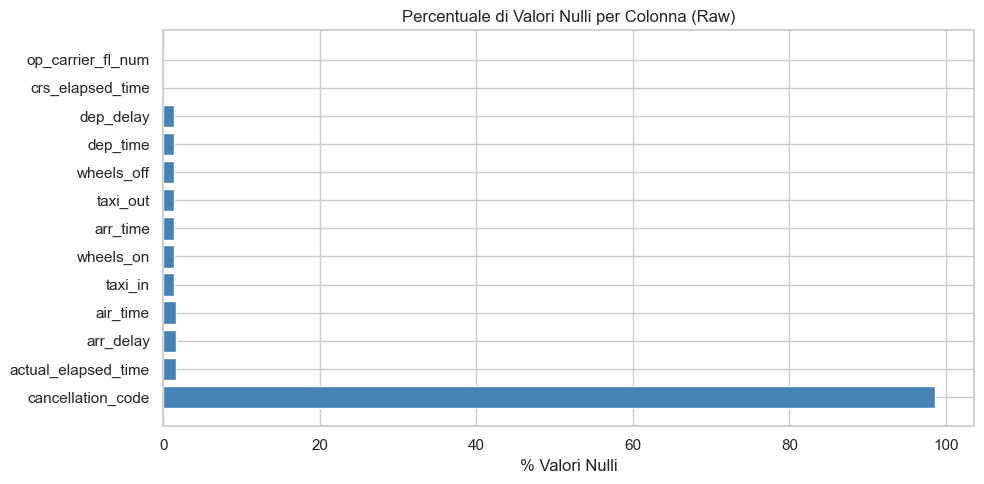

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
null_plot = null_df[null_df.null_count > 0]
ax.barh(null_plot.index, null_plot['null_pct'], color='steelblue')
ax.set_xlabel('% Valori Nulli')
ax.set_title('Percentuale di Valori Nulli per Colonna (Raw)')
plt.tight_layout()
plt.savefig('eda/plots/pre_nulls.png', dpi=150)
plt.show()

## 3. Duplicati Esatti

In [7]:
n_dup = df.duplicated().sum()
print(f'Duplicati esatti: {n_dup} ({n_dup/len(df)*100:.3f}%)')

Duplicati esatti: 0 (0.000%)


## 4. Distribuzione Voli per Mese

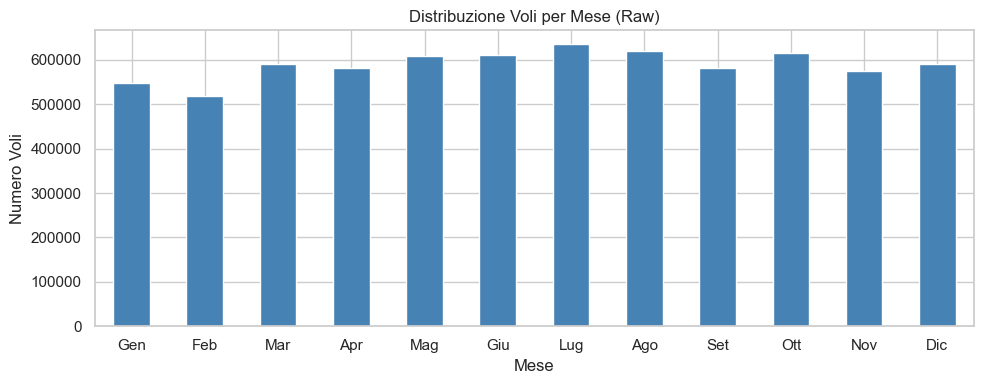

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
df['month'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Mese')
ax.set_ylabel('Numero Voli')
ax.set_title('Distribuzione Voli per Mese (Raw)')
ax.set_xticklabels(['Gen','Feb','Mar','Apr','Mag','Giu','Lug','Ago','Set','Ott','Nov','Dic'], rotation=0)
plt.tight_layout()
plt.savefig('eda/plots/pre_flights_per_month.png', dpi=150)
plt.show()

## 5. Distribuzione Voli per Compagnia

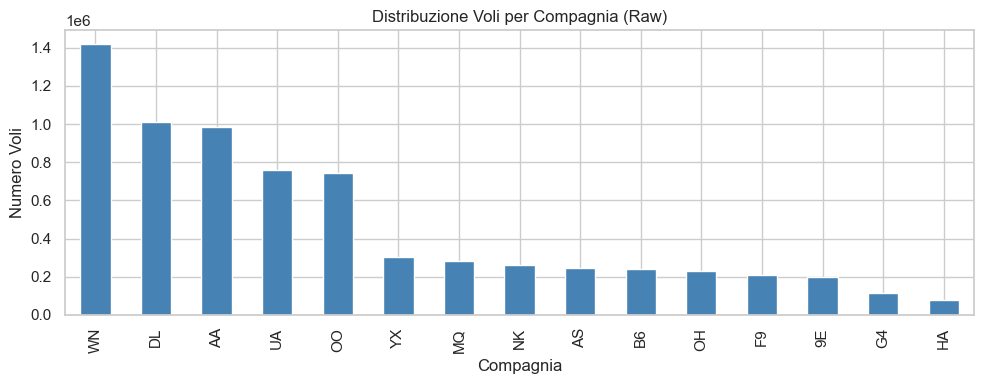

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
df['op_unique_carrier'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Compagnia')
ax.set_ylabel('Numero Voli')
ax.set_title('Distribuzione Voli per Compagnia (Raw)')
plt.tight_layout()
plt.savefig('eda/plots/pre_flights_per_carrier.png', dpi=150)
plt.show()

## 6. Distribuzione dep_delay e arr_delay

dep_delay: min=-96, max=3777, mean=12.7, std=56.1
arr_delay: min=-126, max=3803, mean=7.1, std=58.0


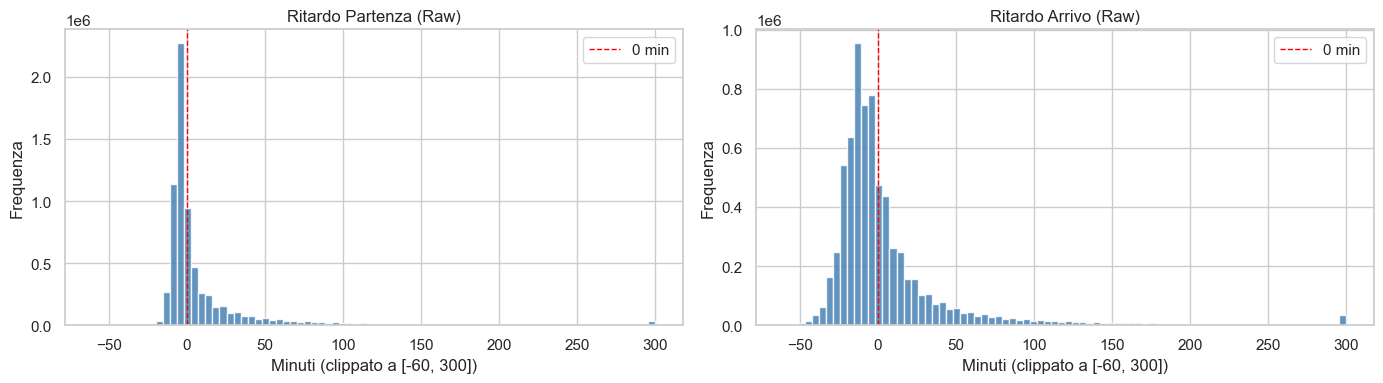

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in zip(axes, ['dep_delay', 'arr_delay'], ['Ritardo Partenza', 'Ritardo Arrivo']):
    data = df[col].dropna()
    data_clip = data.clip(-60, 300)
    ax.hist(data_clip, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linestyle='--', linewidth=1, label='0 min')
    ax.set_xlabel('Minuti (clippato a [-60, 300])')
    ax.set_ylabel('Frequenza')
    ax.set_title(f'{title} (Raw)')
    ax.legend()
    print(f'{col}: min={data.min():.0f}, max={data.max():.0f}, mean={data.mean():.1f}, std={data.std():.1f}')
plt.tight_layout()
plt.savefig('eda/plots/pre_delay_distribution.png', dpi=150)
plt.show()

## 7. Tasso di Cancellazione

Voli cancellati: 96,315 (1.36%)
Voli operati:    6,982,766


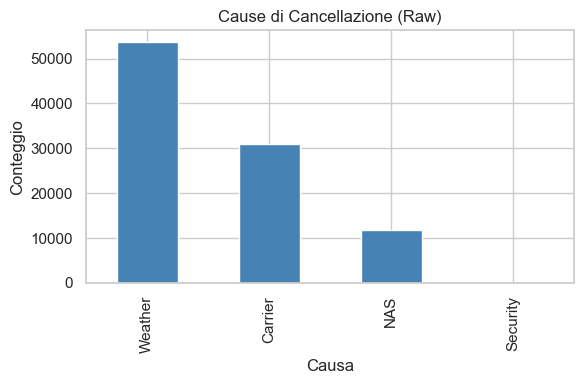

In [11]:
cancelled = df['cancelled'].value_counts()
print(f'Voli cancellati: {cancelled.get(1.0, 0):,} ({cancelled.get(1.0,0)/len(df)*100:.2f}%)')
print(f'Voli operati:    {cancelled.get(0.0, 0):,}')

if df['cancellation_code'].notna().sum() > 0:
    fig, ax = plt.subplots(figsize=(6, 4))
    labels = {'A': 'Carrier', 'B': 'Weather', 'C': 'NAS', 'D': 'Security'}
    cc = df['cancellation_code'].dropna().map(labels).value_counts()
    cc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Cause di Cancellazione (Raw)')
    ax.set_xlabel('Causa')
    ax.set_ylabel('Conteggio')
    plt.tight_layout()
    plt.savefig('eda/plots/pre_cancellation_causes.png', dpi=150)
    plt.show()

## 8. Top 20 Aeroporti di Partenza

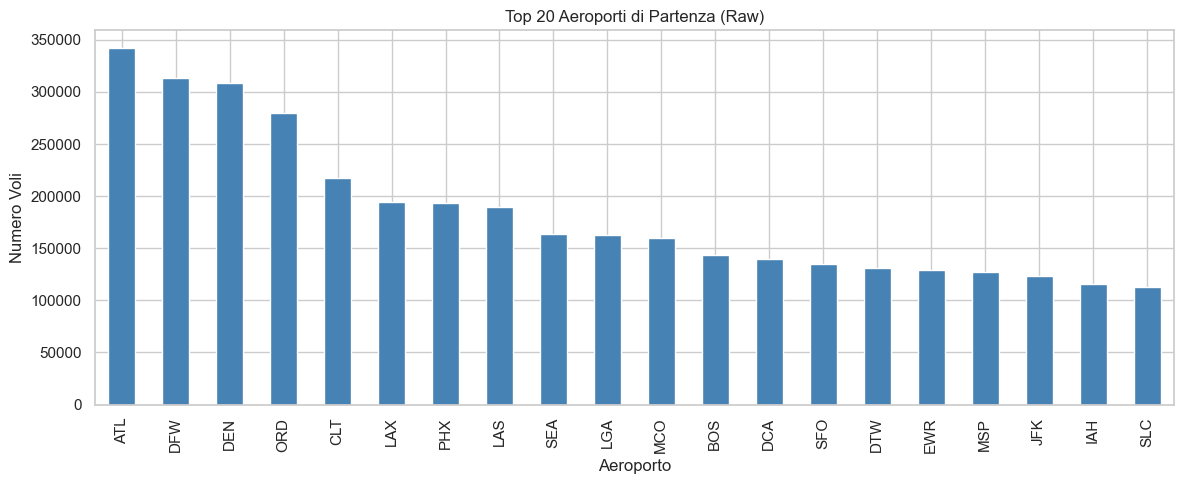

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
df['origin'].value_counts().head(20).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Aeroporti di Partenza (Raw)')
ax.set_xlabel('Aeroporto')
ax.set_ylabel('Numero Voli')
plt.tight_layout()
plt.savefig('eda/plots/pre_top20_airports.png', dpi=150)
plt.show()

## 9. Statistiche Descrittive Ritardi

In [13]:
df[['dep_delay', 'arr_delay', 'carrier_delay', 'weather_delay',
    'nas_delay', 'security_delay', 'late_aircraft_delay']].describe().round(2)

,dep_delay,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,6986111.00,6965267.00,7079081.00,7079081.00,7079081.00,7079081.00,7079081.00
mean,12.68,7.10,5.06,0.88,2.77,0.03,5.93
std,56.06,57.99,35.73,15.43,15.46,1.42,31.06
min,-96.00,-126.00,0.00,0.00,0.00,0.00,0.00
25%,-6.00,-15.00,0.00,0.00,0.00,0.00,0.00
50%,-2.00,-6.00,0.00,0.00,0.00,0.00,0.00
75%,9.00,9.00,0.00,0.00,0.00,0.00,0.00
max,3777.00,3803.00,3689.00,1804.00,2700.00,1164.00,2690.00


## 10. Outlier dep_delay / arr_delay fuori range [-120, 1440]

In [14]:
for col in ['dep_delay', 'arr_delay']:
    out = df[(df[col] < -120) | (df[col] > 1440)]
    print(f'{col}: {len(out)} outlier fuori range [-120, 1440]')
    if len(out) > 0:
        print(out[col].describe())
        print()

dep_delay: 566 outlier fuori range [-120, 1440]
count     566.000000
mean     1766.206714
std       383.300623
min      1441.000000
25%      1502.000000
50%      1625.000000
75%      1855.750000
max      3777.000000
Name: dep_delay, dtype: float64

arr_delay: 568 outlier fuori range [-120, 1440]
count     568.000000
mean     1759.926056
std       390.373698
min      -126.000000
25%      1508.750000
50%      1612.500000
75%      1862.500000
max      3803.000000
Name: arr_delay, dtype: float64

